<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/hcf_smf_g654e_optimal_gsnr_span_repeater_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HCF vs SMF (G.652.D) vs G.654.E
## Optimal GSNR, span length, and repeater count under submarine PFE constraints

이 Colab은 다음 두 모델을 결합한다.

1. 기존 GitHub `dnanf_fig2_hcf_colab.ipynb`의 DNANF-HCF 구조/손실/분산 모델
2. Hedeboe *et al.* 논문의 generalized-droop GN 모델과 식 (6), (7)의 repeater 전력 제한

출력은 모두 입력 파라미터와 수식으로 계산된다. 최종 GSNR, span length 또는 repeater 수를 그래프용 숫자로 직접 입력하지 않는다.

### 최종 출력

- 논문 Figure 2 형식: 6,000/9,000/12,000/15,000 km에서 섬유별 optimal GSNR 대 span length
- 논문 Figure 4 형식: fibre length 대 optimal GSNR, optimal span length, repeater count
- HCF, SMF, G.654.E에 실제 사용한 입력 파라미터 표
- 식 (6), (7)의 요구/공급 repeater power 검산


## 비교 조건

- **FP 수는 변화시키지 않는다.** 세 섬유 모두 동일하게 `FIBRE_PAIRS = 12`를 적용한다.
- 따라서 곡선 차이는 fibre count가 아니라 감쇠, 분산, Kerr 비선형계수 및 HCF IMI에서 발생한다.
- 시스템 파라미터는 논문 Figure 1/2 조건인 18 kV PFE, 4.5 dB NF, 100 GBaud, 112.5 GHz spacing, 4.3 THz bandwidth를 사용한다.
- 운전 power는 `PFE 허용값`, `비선형 최적점 - 2 dB`, `18 dBm` 중 가장 작은 값이다.
- Figure 2에 사용된 원 저자의 2차원 `eta_eo(gain, output power)` 배열은 첨부 파일과 GitHub 저장소에 없으므로, 기존 저장소의 HCF/single-core 설계 노트북과 동일한 2.0--3.1% bounded surrogate를 사용한다. 이 함수는 별도로 분리되어 있어 원 배열 확보 시 교체할 수 있다.
- repeater 수 정의는 저자 Python 코드와 동일하게 $N_{rep}=\lfloor L_{tot}/L_{span}\rfloor$을 사용한다.


In [1]:
import math
from dataclasses import dataclass, replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "legend.fontsize": 8.5,
    "lines.linewidth": 2.0,
})

# ----------------------- User-adjustable comparison range -----------------------
FIBRE_PAIRS = 12                  # Fixed for all three fibres; it is not swept.
LENGTH_GRID_KM = np.arange(6000, 15001, 250)
SPAN_GRID_KM = np.arange(10, 251, 1)
FIGURE2_LENGTHS_KM = (6000, 9000, 12000, 15000)
INCLUDE_HCF_IMI = True

def db_to_lin(x_db):
    return 10.0 ** (np.asarray(x_db, dtype=float) / 10.0)

def lin_to_db(x):
    return 10.0 * np.log10(np.asarray(x, dtype=float))

def dbm_to_w(x_dbm):
    return 1e-3 * db_to_lin(x_dbm)

def w_to_dbm(x_w):
    return lin_to_db(np.asarray(x_w, dtype=float) / 1e-3)


## 1. HCF 구조에서 1550 nm 감쇠와 분산 계산

HCF는 일반 SMF처럼 감쇠와 분산을 단순 상수만 입력하지 않는다. 기존 GitHub 노트북과 동일하게 DNANF 구조에서 다음 과정을 수행한다.

1. tube count, core radius, membrane thickness로 perimeter gap 계산
2. Hasan 유효반경 계수와 modified-capillary 유효굴절률 계산
3. 5-point finite difference로 $D=-(\lambda/c)d^2n_{eff}/d\lambda^2$ 계산
4. 1310/1550 nm 분산 기준값으로 연속 모델 보정
5. surface scattering + anti-resonant leakage로 1550 nm 감쇠 계산


In [2]:
C0_M_PER_S = 299_792_458.0
U01 = 2.4048255577
DB_PER_NEPER = 4.343


@dataclass(frozen=True)
class DNANFGeometry:
    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self):
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self):
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self):
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


def silica_index_sellmeier(wavelength_m):
    wavelength_um = np.asarray(wavelength_m, dtype=float) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = np.ones_like(wavelength_um_sq)
    for bi, ci in zip(b, c_um):
        n_sq += bi * wavelength_um_sq / (wavelength_um_sq - ci**2)
    return np.sqrt(n_sq)


def hasan_radius_coefficients(geometry):
    radius_to_gap = geometry.core_radius_m / geometry.perimeter_gap_m
    n = geometry.tube_count
    nesting = geometry.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n + b3
        + 0.0045 * np.exp(-4.1589 / (nesting * radius_to_gap))
    )
    return float(f1), float(f2)


def effective_index(wavelength_m, geometry, f1, f2):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    effective_radius = f1 * radius * (1.0 - f2 * wavelength_m**2 / (radius * wall))
    return 1.0 - 0.125 * (U01 * wavelength_m / (np.pi * effective_radius)) ** 2


def chromatic_dispersion_ps_nm_km(wavelength_m, geometry, f1, f2, derivative_step_nm=0.20):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    step = derivative_step_nm * 1e-9

    def n_eff(offset):
        return effective_index(wavelength_m + offset, geometry, f1, f2)

    second_derivative = (
        -n_eff(2.0 * step) + 16.0 * n_eff(step) - 30.0 * n_eff(0.0)
        + 16.0 * n_eff(-step) - n_eff(-2.0 * step)
    ) / (12.0 * step**2)
    dispersion_si = -(wavelength_m / C0_M_PER_S) * second_derivative
    return dispersion_si / 1e-6


def calibrate_dispersion(geometry):
    reference_nm = np.array([1310.0, 1550.0])
    reference_d = np.array([2.17, 3.20])
    initial = np.array(hasan_radius_coefficients(geometry))

    def residual(parameters):
        return chromatic_dispersion_ps_nm_km(
            reference_nm * 1e-9, geometry, parameters[0], parameters[1]
        ) - reference_d

    result = least_squares(
        residual, x0=initial,
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac", diff_step=1e-3,
        xtol=1e-13, ftol=1e-13, gtol=1e-13,
    )
    if not result.success or np.max(np.abs(result.fun)) > 1e-3:
        raise RuntimeError(f"HCF dispersion calibration failed: {result.fun}")
    return float(result.x[0]), float(result.x[1])


def capillary_bouncing_ray_loss_db_km(wavelength_m, geometry):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2.0 * np.pi / wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01 / radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0 * np.sqrt(silica_n**2 - 1.0)
    phase = sigma * wall
    te_denominator = 4.0 * np.cos(phase)**2 + (
        kappa / sigma + sigma / kappa
    )**2 * np.sin(phase)**2
    tm_denominator = 4.0 * np.cos(phase)**2 + (
        silica_n**2 * kappa / sigma + sigma / (silica_n**2 * kappa)
    )**2 * np.sin(phase)**2
    alpha_te_per_m = 2.0 * U01 / (radius**2 * k0 * te_denominator)
    alpha_tm_per_m = 2.0 * U01 / (radius**2 * k0 * tm_denominator)
    return 0.5 * (alpha_te_per_m + alpha_tm_per_m) * DB_PER_NEPER * 1000.0


def attenuation_db_km(wavelength_m, geometry):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    reference_alpha = np.array([0.075, 0.120])
    lambda_ref_m = reference_nm[0] * 1e-9
    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm * 1e-9, geometry)
    basis_reference = np.column_stack([
        (lambda_ref_m / (reference_nm * 1e-9))**3,
        (br_ref / br_ref[0])**2,
    ])
    a_surface, a_nested = np.linalg.solve(basis_reference, reference_alpha)
    if a_surface < 0.0 or a_nested < 0.0:
        raise RuntimeError("Calibrated HCF attenuation contributions must be non-negative.")
    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    return (
        a_surface * (lambda_ref_m / wavelength_m)**3
        + a_nested * (br / br_ref[0])**2
    )


HCF_GEOMETRY = DNANFGeometry()
HCF_F1, HCF_F2 = calibrate_dispersion(HCF_GEOMETRY)
HCF_ALPHA_1550 = float(attenuation_db_km(np.array([1550e-9]), HCF_GEOMETRY)[0])
HCF_D_1550 = float(chromatic_dispersion_ps_nm_km(
    np.array([1550e-9]), HCF_GEOMETRY, HCF_F1, HCF_F2
)[0])

print(f"Calculated HCF alpha(1550 nm) = {HCF_ALPHA_1550:.4f} dB/km")
print(f"Calculated HCF D(1550 nm)     = {HCF_D_1550:.4f} ps/(nm km)")
print(f"Calibrated HCF f1, f2         = {HCF_F1:.6f}, {HCF_F2:.6f}")


Calculated HCF alpha(1550 nm) = 0.0750 dB/km
Calculated HCF D(1550 nm)     = 3.2000 ps/(nm km)
Calibrated HCF f1, f2         = 1.583810, 0.244140


In [3]:
@dataclass(frozen=True)
class FibreParameters:
    key: str
    label: str
    attenuation_db_per_km: float
    dispersion_ps_nm_km: float
    gamma_per_w_km: float
    effective_area_um2: float | None
    imi_db_per_km: float | None
    source_basis: str

    @property
    def imi_linear_per_km(self):
        if self.imi_db_per_km is None:
            return 0.0
        return 10.0 ** (self.imi_db_per_km / 10.0)


FIBRES = {
    "HCF": FibreParameters(
        key="HCF", label="DNANF HCF",
        attenuation_db_per_km=HCF_ALPHA_1550,
        dispersion_ps_nm_km=HCF_D_1550,
        gamma_per_w_km=5e-4,
        effective_area_um2=None,
        imi_db_per_km=-52.0 if INCLUDE_HCF_IMI else None,
        source_basis="Existing GitHub DNANF model; gamma and IMI from its HCFLink",
    ),
    "SMF": FibreParameters(
        key="SMF", label="SMF (G.652.D)",
        attenuation_db_per_km=0.18,
        dispersion_ps_nm_km=18.0,
        gamma_per_w_km=1.30,
        effective_area_um2=85.0,
        imi_db_per_km=None,
        source_basis="Corning SMF-28 Ultra max 1550-nm alpha/D; representative gamma",
    ),
    "G654E": FibreParameters(
        key="G654E", label="G.654.E (SCUBA 110)",
        attenuation_db_per_km=0.15,
        dispersion_ps_nm_km=21.0,
        gamma_per_w_km=0.81,
        effective_area_um2=110.0,
        imi_db_per_km=None,
        source_basis="Hedeboe paper Table 1; SCUBA 110 product basis",
    ),
}

fibre_input_table = pd.DataFrame([
    {
        "Fibre": f.label,
        "alpha @1550 (dB/km)": f.attenuation_db_per_km,
        "D @1550 (ps/nm/km)": f.dispersion_ps_nm_km,
        "gamma (1/W/km)": f.gamma_per_w_km,
        "Aeff (um2)": f.effective_area_um2,
        "IMI (dB/km)": f.imi_db_per_km,
        "Basis": f.source_basis,
    }
    for f in FIBRES.values()
])
print(fibre_input_table.to_string(index=False))


              Fibre  alpha @1550 (dB/km)  D @1550 (ps/nm/km)  gamma (1/W/km)  Aeff (um2)  IMI (dB/km)                                                          Basis
          DNANF HCF                0.075            3.200004          0.0005         NaN        -52.0    Existing GitHub DNANF model; gamma and IMI from its HCFLink
      SMF (G.652.D)                0.180           18.000000          1.3000        85.0          NaN Corning SMF-28 Ultra max 1550-nm alpha/D; representative gamma
G.654.E (SCUBA 110)                0.150           21.000000          0.8100       110.0          NaN                 Hedeboe paper Table 1; SCUBA 110 product basis


## 2. Generalized-droop GN model과 repeater power

저자 `snr_calculator_Silas.py`의 핵심 식을 self-contained 형태로 구현한다.

- ASE: $P_{ASE}=hf_0NF(G-1)R_s$
- GN 비선형계수: 논문 식 (5)
- additive/redistribution droop: $\chi_a$, $\chi_r$
- 누적 GSNR: $\mathrm{GSNR}=\{[\chi_a^{-1}\chi_r^{-1}]^{N_{rep}}-1\}^{-1}$

식 (6), (7)은 다음처럼 직접 검산한다.

$$P_{rep,required}=\frac{2N_{FP}P_s}{(1-\epsilon)\eta_{eo}}$$

$$P_{rep,supplied}=\frac{V_{PFE}^2}{4R_0L_{tot}N_{rep}}$$

여기서 $P_s=N_{ch}P_{ch}$는 한 amplifier의 전체 WDM 출력이다. candidate power가 `required <= supplied`일 때만 사용 가능하다.


In [4]:
H_PLANCK = 6.62607015e-34
C_NM_PER_S = 2.99792458e17


@dataclass(frozen=True)
class SystemParameters:
    wavelength_nm: float = 1550.0
    noise_figure_db: float = 4.5
    symbol_rate_hz: float = 100e9
    channel_spacing_hz: float = 112.5e9
    bandwidth_hz: float = 4.3e12
    pfe_voltage_v: float = 18e3
    conductor_resistance_ohm_per_km: float = 1.0
    circuit_fraction: float = 0.10
    fibre_pairs: int = FIBRE_PAIRS
    nl_backoff_db: float = 2.0
    launch_power_limit_dbm: float = 18.0

    @property
    def n_channels(self):
        return self.bandwidth_hz / self.channel_spacing_hz


SYSTEM = SystemParameters()


def span_count_and_length(total_length_km, nominal_span_km):
    n_repeaters = max(1, int(np.floor(total_length_km / nominal_span_km)))
    actual_span_km = total_length_km / n_repeaters
    return n_repeaters, actual_span_km


def gn_alpha_nli(actual_span_km, fibre, system=SYSTEM):
    alpha_lin = fibre.attenuation_db_per_km / 4.343
    dispersion_s_per_km_nm = fibre.dispersion_ps_nm_km * 1e-12
    beta2 = abs(
        -dispersion_s_per_km_nm * system.wavelength_nm**2
        / (2.0 * np.pi * C_NM_PER_S)
    )
    leff = (1.0 - np.exp(-alpha_lin * actual_span_km)) / alpha_lin
    leff_asymptotic = 1.0 / alpha_lin
    asinh_argument = (
        np.pi**2 / 2.0 * beta2 * leff_asymptotic * system.symbol_rate_hz**2
        * system.n_channels ** (
            2.0 * system.symbol_rate_hz / system.channel_spacing_hz
        )
    )
    return (
        (8.0 / 27.0) * fibre.gamma_per_w_km**2 * leff**2
        * np.arcsinh(asinh_argument)
        / (np.pi * beta2 * leff_asymptotic * system.symbol_rate_hz**2)
    )


def generalized_droop_gsnr(total_launch_power_w, total_length_km, nominal_span_km,
                           fibre, system=SYSTEM):
    ps = np.asarray(total_launch_power_w, dtype=float)
    n_repeaters, actual_span_km = span_count_and_length(total_length_km, nominal_span_km)
    pch = ps / system.n_channels
    frequency_hz = C_NM_PER_S / system.wavelength_nm
    span_gain = db_to_lin(fibre.attenuation_db_per_km * actual_span_km)
    pase = (
        H_PLANCK * frequency_hz * db_to_lin(system.noise_figure_db)
        * system.symbol_rate_hz * (span_gain - 1.0)
    )
    chi_a = 1.0 / (1.0 + pase / pch)

    alpha_nli = gn_alpha_nli(actual_span_km, fibre, system)
    inverse_snr_nli = alpha_nli * pch**2
    inverse_snr_imi = fibre.imi_linear_per_km * actual_span_km
    chi_r = 1.0 / (1.0 + inverse_snr_nli + inverse_snr_imi)

    exponent = n_repeaters * (-np.log(chi_a) - np.log(chi_r))
    denominator = np.empty_like(exponent, dtype=float)
    safe = exponent < 700.0
    denominator[safe] = np.expm1(exponent[safe])
    denominator[~safe] = np.inf
    return 1.0 / denominator


system_input_table = pd.DataFrame([
    ("V_PFE", SYSTEM.pfe_voltage_v / 1e3, "kV"),
    ("R0", SYSTEM.conductor_resistance_ohm_per_km, "ohm/km"),
    ("epsilon", 100 * SYSTEM.circuit_fraction, "%"),
    ("N_FP (fixed)", SYSTEM.fibre_pairs, "pairs"),
    ("NF", SYSTEM.noise_figure_db, "dB"),
    ("Rs", SYSTEM.symbol_rate_hz / 1e9, "GBaud"),
    ("Delta f", SYSTEM.channel_spacing_hz / 1e9, "GHz"),
    ("B", SYSTEM.bandwidth_hz / 1e12, "THz"),
    ("effective Nch", SYSTEM.n_channels, "channels"),
    ("NL backoff", SYSTEM.nl_backoff_db, "dB"),
    ("hardware launch limit", SYSTEM.launch_power_limit_dbm, "dBm/amplifier"),
], columns=["System input", "Value", "Unit"])
print(system_input_table.to_string(index=False))


         System input      Value          Unit
                V_PFE  18.000000            kV
                   R0   1.000000        ohm/km
              epsilon  10.000000             %
         N_FP (fixed)  12.000000         pairs
                   NF   4.500000            dB
                   Rs 100.000000         GBaud
              Delta f 112.500000           GHz
                    B   4.300000           THz
        effective Nch  38.222222      channels
           NL backoff   2.000000            dB
hardware launch limit  18.000000 dBm/amplifier


In [5]:
def eta_eo_surrogate(gain_db, total_output_power_w):
    '''Replaceable 2.0--3.1% model for the missing eta_eo(gain, output) table.'''
    output_w = np.maximum(np.asarray(total_output_power_w, dtype=float), 1e-12)
    pout_dbm = w_to_dbm(output_w)
    gain_term = np.clip((gain_db - 7.0) / 5.0, 0.0, 1.0)
    output_term = np.clip((pout_dbm - 5.0) / 13.0, 0.0, 1.0) ** 2
    return 0.020 + 0.011 * gain_term * output_term


POWER_SEARCH_DBM = np.linspace(-30.0, 30.0, 1201)
POWER_SEARCH_W = dbm_to_w(POWER_SEARCH_DBM)


def repeater_power_required_w(total_output_power_w, eta_eo, system=SYSTEM):
    return (
        2.0 * system.fibre_pairs * total_output_power_w
        / ((1.0 - system.circuit_fraction) * eta_eo)
    )


def repeater_power_supplied_w(total_length_km, n_repeaters, system=SYSTEM):
    return (
        system.pfe_voltage_v**2
        / (4.0 * system.conductor_resistance_ohm_per_km
           * total_length_km * n_repeaters)
    )


def optimize_operating_point(total_length_km, nominal_span_km, fibre, system=SYSTEM):
    n_repeaters, actual_span_km = span_count_and_length(total_length_km, nominal_span_km)
    gsnr_curve = generalized_droop_gsnr(
        POWER_SEARCH_W, total_length_km, nominal_span_km, fibre, system
    )
    p_nl_w = POWER_SEARCH_W[np.argmax(gsnr_curve)]
    p_backoff_w = p_nl_w / db_to_lin(system.nl_backoff_db)
    p_hardware_w = dbm_to_w(system.launch_power_limit_dbm)

    gain_db = fibre.attenuation_db_per_km * actual_span_km
    eta_candidates = eta_eo_surrogate(gain_db, POWER_SEARCH_W)
    required = repeater_power_required_w(POWER_SEARCH_W, eta_candidates, system)
    supplied = repeater_power_supplied_w(total_length_km, n_repeaters, system)
    feasible = required <= supplied
    if not np.any(feasible):
        raise RuntimeError("No PFE-feasible launch power found in search grid.")
    p_pfe_w = POWER_SEARCH_W[np.where(feasible)[0][-1]]

    limits = {"PFE": p_pfe_w, "NL-2 dB": p_backoff_w, "18 dBm": p_hardware_w}
    active_constraint = min(limits, key=limits.get)
    p_used_w = limits[active_constraint]
    eta_used = float(eta_eo_surrogate(gain_db, p_used_w))
    required_used = float(repeater_power_required_w(p_used_w, eta_used, system))

    gsnr_used = float(lin_to_db(generalized_droop_gsnr(
        np.array([p_used_w]), total_length_km, nominal_span_km, fibre, system
    )[0]))
    return {
        "total_length_km": float(total_length_km),
        "fibre": fibre.key,
        "label": fibre.label,
        "nominal_span_km": float(nominal_span_km),
        "actual_span_km": float(actual_span_km),
        "n_repeaters": int(n_repeaters),
        "gain_db": float(gain_db),
        "eta_eo": eta_used,
        "p_nl_dbm": float(w_to_dbm(p_nl_w)),
        "p_pfe_dbm": float(w_to_dbm(p_pfe_w)),
        "p_used_dbm": float(w_to_dbm(p_used_w)),
        "active_constraint": active_constraint,
        "p_rep_required_w": required_used,
        "p_rep_supplied_w": float(supplied),
        "power_margin_w": float(supplied - required_used),
        "optimal_gsnr_db": gsnr_used,
    }


def optimize_span_for_length(total_length_km, fibre, span_grid_km=SPAN_GRID_KM):
    candidates = pd.DataFrame([
        optimize_operating_point(total_length_km, span, fibre)
        for span in span_grid_km
    ])
    best_index = candidates["optimal_gsnr_db"].idxmax()
    return candidates.loc[best_index].to_dict(), candidates


# Basic consistency tests before the full sweep.
for fibre in FIBRES.values():
    test_point = optimize_operating_point(9000, 75, fibre)
    assert np.isfinite(test_point["optimal_gsnr_db"])
    assert test_point["p_rep_required_w"] <= test_point["p_rep_supplied_w"] + 1e-10
print("GSNR and Eq. (6)/(7) power checks: PASS")


GSNR and Eq. (6)/(7) power checks: PASS


## 3. 논문 Figure 2 형식 - span length별 제약 optimal GSNR

각 span에서 launch power 전체를 sweep한 뒤, PFE/NL-backoff/18 dBm 제약하의 최적 GSNR을 계산한다. 별표는 해당 거리와 섬유에서 GSNR이 최대가 되는 span이다.


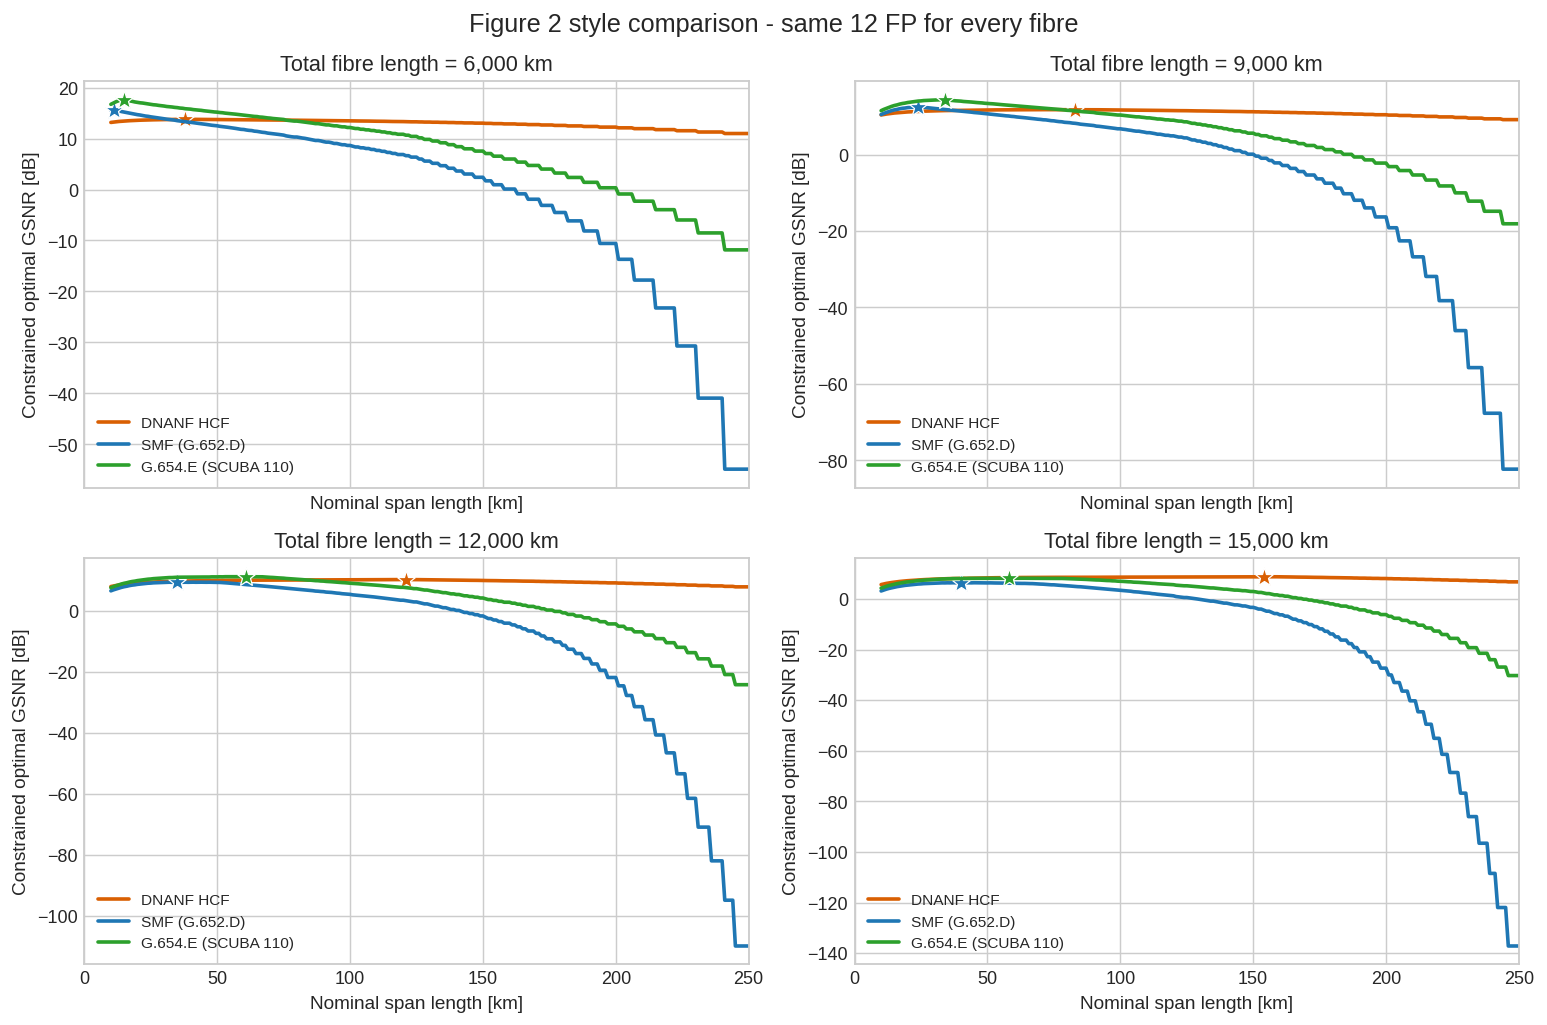

In [6]:
FIGURE2_RESULTS = {}
colours = {"HCF": "#d95f02", "SMF": "#1f77b4", "G654E": "#2ca02c"}

fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), sharex=True, sharey=False)
for ax, total_length_km in zip(axes.flat, FIGURE2_LENGTHS_KM):
    for key, fibre in FIBRES.items():
        best, candidates = optimize_span_for_length(total_length_km, fibre)
        FIGURE2_RESULTS[(total_length_km, key)] = (best, candidates)
        ax.plot(
            candidates["nominal_span_km"], candidates["optimal_gsnr_db"],
            color=colours[key], label=fibre.label,
        )
        ax.plot(
            best["nominal_span_km"], best["optimal_gsnr_db"],
            marker="*", markersize=11, linestyle="none",
            color=colours[key], markeredgecolor="white", markeredgewidth=0.7,
        )
    ax.set_title(f"Total fibre length = {total_length_km:,} km")
    ax.set_xlim(0, 250)
    ax.set_xlabel("Nominal span length [km]")
    ax.set_ylabel("Constrained optimal GSNR [dB]")
    ax.legend(loc="best")

fig.suptitle("Figure 2 style comparison - same 12 FP for every fibre", fontsize=14)
fig.tight_layout()
plt.show()


## 4. 논문 Figure 4 형식 - fibre length별 최적 span과 repeater 수

각 fibre length마다 다음 이중 최적화를 수행한다.

1. 각 span candidate에서 launch power를 sweep해 제약 optimal GSNR 계산
2. 모든 span candidate 중 GSNR이 가장 큰 span 선택
3. 선택된 span으로 $N_{rep}=\lfloor L_{tot}/L_{span}\rfloor$ 계산

동일 bandwidth와 동일 FP 수에서는 Shannon capacity가 GSNR에 단조 증가하므로, GSNR 최대 span은 capacity 최대 span과 동일하다.


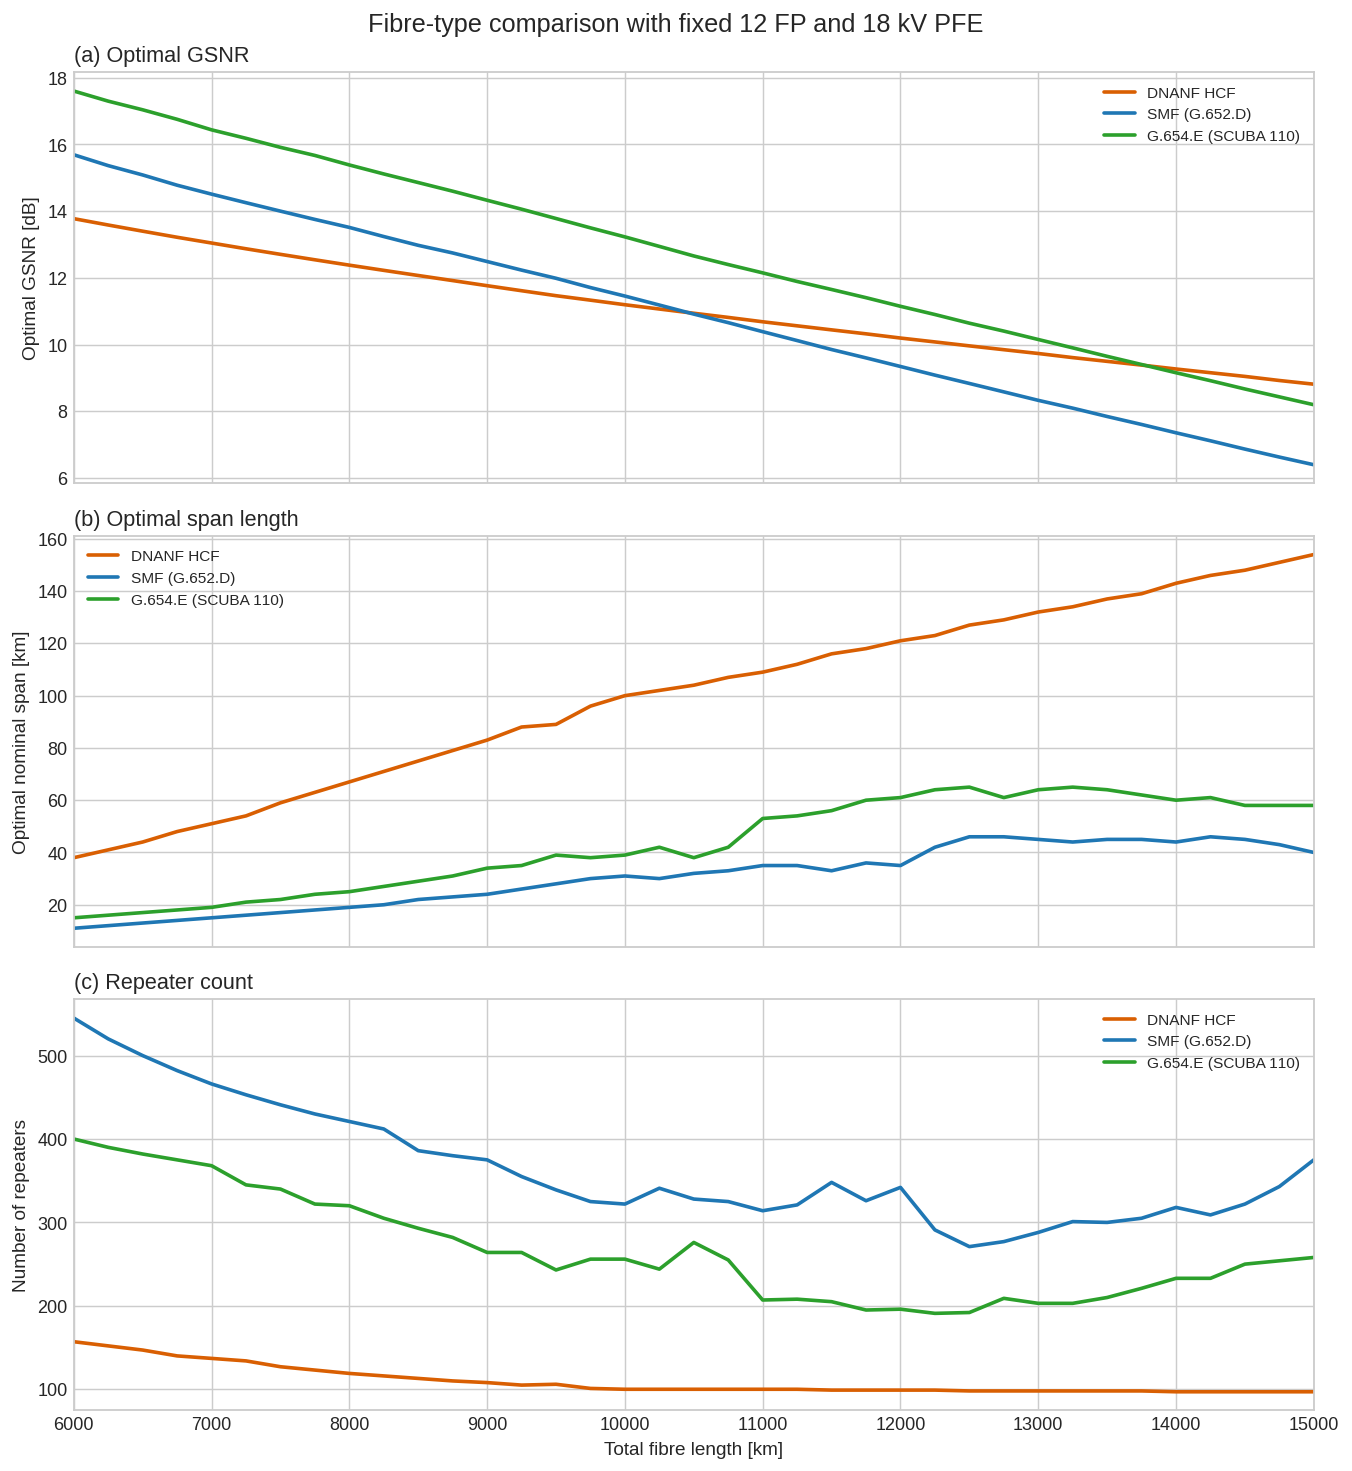

In [7]:
optimum_rows = []
for key, fibre in FIBRES.items():
    for total_length_km in LENGTH_GRID_KM:
        best, _ = optimize_span_for_length(total_length_km, fibre)
        optimum_rows.append(best)

OPTIMUM_RESULTS = pd.DataFrame(optimum_rows)

fig, axes = plt.subplots(3, 1, figsize=(10.5, 11.5), sharex=True)
panels = [
    ("optimal_gsnr_db", "Optimal GSNR [dB]", "(a) Optimal GSNR"),
    ("nominal_span_km", "Optimal nominal span [km]", "(b) Optimal span length"),
    ("n_repeaters", "Number of repeaters", "(c) Repeater count"),
]

for ax, (column, ylabel, title) in zip(axes, panels):
    for key, fibre in FIBRES.items():
        data = OPTIMUM_RESULTS[OPTIMUM_RESULTS["fibre"] == key]
        ax.plot(
            data["total_length_km"], data[column],
            color=colours[key], label=fibre.label,
        )
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left")
    ax.legend(loc="best")

axes[-1].set_xlabel("Total fibre length [km]")
axes[-1].set_xlim(LENGTH_GRID_KM.min(), LENGTH_GRID_KM.max())
fig.suptitle("Fibre-type comparison with fixed 12 FP and 18 kV PFE", fontsize=14)
fig.tight_layout()
plt.show()


In [8]:
benchmark_lengths = [6000, 9000, 12000, 15000]
summary = OPTIMUM_RESULTS[
    OPTIMUM_RESULTS["total_length_km"].isin(benchmark_lengths)
][[
    "total_length_km", "label", "optimal_gsnr_db", "nominal_span_km",
    "actual_span_km", "n_repeaters", "p_used_dbm", "active_constraint",
    "eta_eo", "p_rep_required_w", "p_rep_supplied_w", "power_margin_w",
]].copy()
summary["eta_eo_percent"] = 100.0 * summary.pop("eta_eo")
summary = summary.sort_values(["total_length_km", "label"])

print("Benchmark results calculated by the nested launch-power/span optimization")
print(summary.round({
    "optimal_gsnr_db": 3, "nominal_span_km": 1, "actual_span_km": 3,
    "p_used_dbm": 2, "eta_eo_percent": 3,
    "p_rep_required_w": 3, "p_rep_supplied_w": 3, "power_margin_w": 3,
}).to_string(index=False))

assert np.all(summary["power_margin_w"] >= -1e-9)
assert set(summary["label"]) == {f.label for f in FIBRES.values()}
assert len(summary) == len(benchmark_lengths) * len(FIBRES)
print("\nFinal result validation: PASS")


Benchmark results calculated by the nested launch-power/span optimization
 total_length_km               label  optimal_gsnr_db  nominal_span_km  actual_span_km  n_repeaters  p_used_dbm active_constraint  p_rep_required_w  p_rep_supplied_w  power_margin_w  eta_eo_percent
          6000.0           DNANF HCF           13.776             38.0          38.217          157       18.00            18 dBm            84.128            85.987           1.860           2.000
          6000.0 G.654.E (SCUBA 110)           17.602             15.0          15.000          400       13.90           NL-2 dB            32.729            33.750           1.021           2.000
          6000.0       SMF (G.652.D)           15.691             11.0          11.009          545       12.65               PFE            24.544            24.771           0.227           2.000
          9000.0           DNANF HCF           11.766             83.0          83.333          108       17.95               PFE     

## 입력값 해석과 주의사항

- **HCF:** 1550 nm 감쇠와 분산은 DNANF 구조 알고리즘으로 계산된다. `gamma=5e-4 1/(W km)`, `IMI=-52 dB/km`는 기존 GitHub `HCFLink` 입력을 사용한다. IMI 영향을 빼고 이상적인 HCF만 보고 싶으면 `INCLUDE_HCF_IMI=False`로 바꾼다.
- **SMF (G.652.D):** Corning SMF-28 Ultra의 1550 nm 최대 감쇠 0.18 dB/km와 최대 분산 18 ps/(nm km)를 사용했다. `Aeff=85 um2`, `gamma=1.30 1/(W km)`는 대표 시스템 모델값이다.
- **G.654.E:** 논문 Table 1/SCUBA 110 기준 `alpha=0.15 dB/km`, `D=21 ps/(nm km)`, `Aeff=110 um2`, `gamma=0.81 1/(W km)`를 사용했다.
- **공통:** fibre pairs, NF, baud rate, channel spacing, bandwidth, V_PFE, R0, epsilon은 모두 동일하다.
- **EDFA 효율:** 저자 optimizer가 요구하는 2-D lookup table은 제공되지 않았다. `eta_eo_surrogate()`는 기존 저장소 설계 노트북과 동일한 2.0--3.1% gain/output-power 함수이며, 실제 표를 받으면 이 함수만 교체하면 된다.
- 이 결과는 fibre 종류의 상대 비교용이다. 실제 케이블 설계에는 splice/FIFO loss, gain tilt, wavelength-dependent NF, GAWBS, ageing margin과 공급사별 실제 fibre data를 추가해야 한다.

## References

1. Existing GitHub HCF notebook: `paper/hcf-optimum-launch-power-reproduction/dnanf_fig2_hcf_colab.ipynb`.
2. S. L. Hedeboe et al., *Capacity and Cost Investigations of Long-Span-Length, High-Number Spatial-Pairs Trans-Oceanic Cables*, SubOptic 2025.
3. A. Bononi et al., *The Generalized Droop Formula for Low Signal to Noise Ratio Optical Links*, JLT 38(8), 2020.
4. P. Poggiolini et al., *The GN-model of fiber non-linear propagation and its applications*, JLT 32(4), 2014.
5. Corning SMF-28 Ultra Product Information, PI-1424, July 2025.
6. Lightera/OFS TeraWave SCUBA 110 Ocean Optical Fiber product information.
